In [ ]:
# Import libraries for data analysis, numerical computations, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## Data Loading & First Look


In [ ]:
# Load the thyroid dataset into a DataFrame
dataset_path = 'thyroidDF.csv'
df_raw = pd.read_csv(dataset_path)

In [ ]:
df_raw.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,...,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,...,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047


## Data Understanding

This section provides an overview of the dataset structure, variables, and statistical characteristics.

In [ ]:
# Display dataset structure, data types, and missing values
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   object 
 2   on_thyroxine         9172 non-null   object 
 3   query_on_thyroxine   9172 non-null   object 
 4   on_antithyroid_meds  9172 non-null   object 
 5   sick                 9172 non-null   object 
 6   pregnant             9172 non-null   object 
 7   thyroid_surgery      9172 non-null   object 
 8   I131_treatment       9172 non-null   object 
 9   query_hypothyroid    9172 non-null   object 
 10  query_hyperthyroid   9172 non-null   object 
 11  lithium              9172 non-null   object 
 12  goitre               9172 non-null   object 
 13  tumor                9172 non-null   object 
 14  hypopituitary        9172 non-null   object 
 15  psych                9172 non-null   o

In [ ]:
# Correct data types
df_raw['patient_id'] = df_raw['patient_id'].astype(str)

In [ ]:
# Statistical summary
df_raw.describe()

,age,TSH,T3,TT4,T4U,FTI,TBG
count,9172.000000,8330.000000,6568.000000,8730.000000,8363.000000,8370.000000,349.000000
mean,73.555822,5.218403,1.970629,108.700305,0.976056,113.640746,29.870057
std,1183.976718,24.184006,0.887579,37.522670,0.200360,41.551650,21.080504
min,1.000000,0.005000,0.050000,2.000000,0.170000,1.400000,0.100000
25%,37.000000,0.460000,1.500000,87.000000,0.860000,93.000000,21.000000
50%,55.000000,1.400000,1.900000,104.000000,0.960000,109.000000,26.000000
75%,68.000000,2.700000,2.300000,126.000000,1.065000,128.000000,31.000000
max,65526.000000,530.000000,18.000000,600.000000,2.330000,881.000000,200.000000


### Observation

- The dataset contains demographic, clinical, medication, and laboratory measurement variables.
- Several laboratory measurements are numerical and require further analysis.
- The patient_id column is an identifier and was converted to string format.

## Data Quality Assessment

<Axes: >

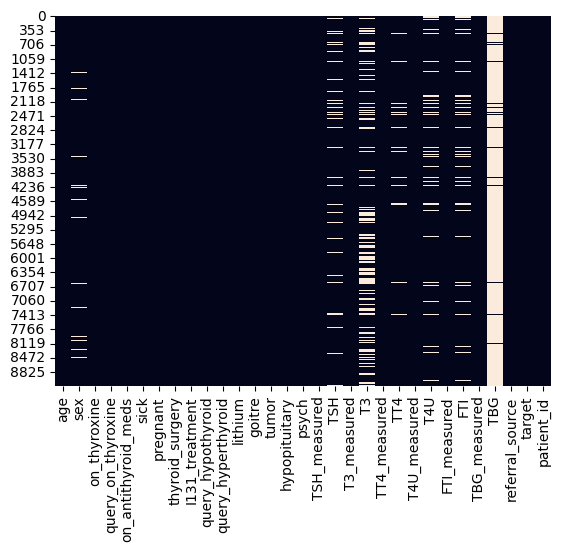

In [ ]:
# Visualize the distribution of missing values across all features
sns.heatmap(df_raw.isnull(), cbar=False)

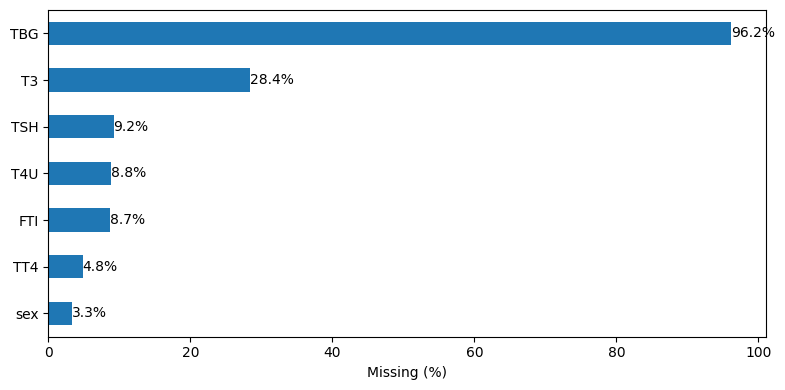

In [ ]:

# Visualize the percentage of missing values for features containing missing data

missing = (df_raw.isnull().mean() * 100)
missing = missing[missing > 0].sort_values()

ax = missing.plot.barh(figsize=(8, 4))

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.xlabel("Missing (%)")
plt.tight_layout()
plt.show()


In [ ]:
# Check for inconsistencies between hormone values and their measured flags
hormones = ['TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']

for h in hormones:
    inconsistent = df_raw[
        ((df_raw[f'{h}_measured'] == 't') & (df_raw[h].isna())) |
        ((df_raw[f'{h}_measured'] == 'f') & (df_raw[h].notna()))
    ]
    
    print(f"{h}: {len(inconsistent)} inconsistent rows")

TSH: 0 inconsistent rows
T3: 0 inconsistent rows
TT4: 0 inconsistent rows
T4U: 0 inconsistent rows
FTI: 0 inconsistent rows
TBG: 0 inconsistent rows


Result: 
 - Missing hormone values occur only when the corresponding test was not measured. Since the missingness is structural, imputation is not appropriate.


In [ ]:
# Patients where TBG is available
tbg_df =df_raw[df_raw["TBG"].notna()]

print(f"Number of patients with TBG values: {len(tbg_df)}")
display(tbg_df.head())

Number of patients with TBG values: 349


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047
5,60,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803048
6,77,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,21.0,other,-,840803068


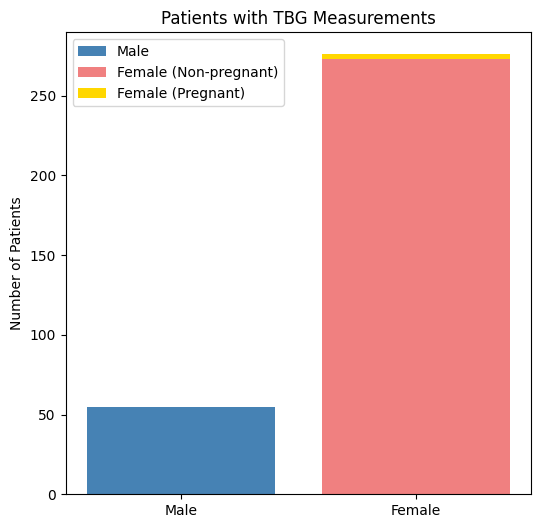

In [ ]:

# Counts
male = (tbg_df["sex"] == "M").sum()

female_nonpreg = (
    (tbg_df["sex"] == "F") &
    (tbg_df["pregnant"] == "f")
).sum()

female_preg = (
    (tbg_df["sex"] == "F") &
    (tbg_df["pregnant"] == "t")
).sum()

# Plot
plt.figure(figsize=(6,6))

# Male bar (single color)
plt.bar(
    "Male",
    male,
    color="steelblue",
    label="Male"
)

# Female bar (non-pregnant part)
plt.bar(
    "Female",
    female_nonpreg,
    color="lightcoral",
    label="Female (Non-pregnant)"
)

# Pregnant portion stacked on top
plt.bar(
    "Female",
    female_preg,
    bottom=female_nonpreg,
    color="gold",
    label="Female (Pregnant)"
)

plt.ylabel("Number of Patients")
plt.title("Patients with TBG Measurements")
plt.legend()
plt.show()

### Insight: TBG Measurements

TBG (Thyroxine-Binding Globulin) is a specialized thyroid test and was measured for only **349 of 9,172 patients**, resulting in **96.2% missing values**. Most of the available TBG measurements were from female patients, with only a small proportion from pregnant women.

Due to the extremely high missingness and the limited number of available observations, TBG was excluded from subsequent statistical analyses.

## Data Cleaning and Validation

A separate copy of the dataset is created to preserve the original data while applying cleaning and validation procedures.

In [ ]:
# Create a copy for data cleaning
df = df_raw.copy()

In [ ]:
# Check for duplicate records excluding patient_id,
# since patient_id is unique for each patient.
df.duplicated(subset=df.columns.drop('patient_id')).sum()

np.int64(10)

In [ ]:
# Remove duplicates
df = df.drop_duplicates(subset=df.columns.drop('patient_id'))

In [ ]:
# verify duplicate removal
df.duplicated(subset=df.columns.drop('patient_id')).sum()

np.int64(0)

In [ ]:
# Check records with unrealistic age values
df[df['age'] > 120]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
2976,455,F,f,f,f,f,f,f,f,f,...,118.0,t,1.13,t,104.0,f,NaN,SVI,-,850530001
5710,65511,M,f,f,f,f,f,f,f,f,...,113.0,t,1.08,t,104.0,f,NaN,other,-,860210008
6392,65512,M,f,f,f,f,f,f,f,f,...,112.0,t,0.84,t,133.0,f,NaN,other,-,860403050
8105,65526,F,f,f,f,f,f,f,f,f,...,132.0,t,1.02,t,129.0,f,NaN,other,-,861014041


In [ ]:
# Remove records with unrealistic age values
df = df[df['age'] <= 120]

In [ ]:
# verify age removal
df[df['age'] > 120]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id


In [ ]:
# Check for pregnant male patients
df[(df['pregnant'] == 't') & (df['sex'] == 'M')]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id


In [ ]:
# Check pregnancies at unrealistic ages
df[
    (df['pregnant'] == 't') &
    ((df['age'] < 12) | (df['age'] > 55))
]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
4016,75,F,f,f,f,f,t,f,f,f,...,139.0,t,1.53,t,91.0,f,NaN,other,I,850820050
4829,73,NaN,f,f,f,f,t,f,f,f,...,110.0,t,1.28,t,85.0,f,NaN,other,-,851024089
6617,73,F,t,f,f,f,t,f,f,f,...,121.0,t,0.91,t,134.0,f,NaN,other,-,860421046
8908,62,F,f,f,f,f,t,f,f,f,...,154.0,t,1.75,t,88.0,f,NaN,SVHC,I,861217046


In [ ]:
# Remove pregnancies at unrealistic ages
df = df[
    ~(
        (df['pregnant'] == 't') &
        ((df['age'] < 12) | (df['age'] > 55))
    )
]

In [ ]:
# Verify unrealistic pregnancy removal
(
    (df['pregnant'] == 't') &
    ((df['age'] < 12) | (df['age'] > 55))
).sum()

np.int64(0)

---
## Diagnosis Code Mapping

### Diagnosis Code Reference (UCI specification)

```
Group              Code  Condition
─────────────────────────────────────────────────────
Hyperthyroid         A   Hyperthyroid
                     B   T3 Toxic
                     C   Toxic Goitre
                     D   Secondary Toxic
Hypothyroid          E   Hypothyroid
                     F   Primary Hypothyroid
                     G   Compensated Hypothyroid
                     H   Secondary Hypothyroid
Binding Protein      I   Increased Binding Protein
                     J   Decreased Binding Protein
                     S   Elevated TBG
General Health       K   Concurrent Non-Thyroidal Illness
Replacement Therapy  L   Consistent With Replacement Therapy
                     M   Underreplaced
                     N   Overreplaced
Antithyroid Tx       O   Antithyroid Drugs
                     P   I131 Treatment
                     Q   Surgery
Miscellaneous        R   Discordant Assay Results
                     T   Elevated Thyroid Hormones
```

**`X|Y` notation:** *"consistent with X, but more likely Y"* — the last code (Y) is used as the primary diagnosis.  
**Compound codes (e.g. GK):** patient has both conditions — first letter is used as the primary grouping.


In [ ]:
# Map diagnosis codes to descriptive names and broader diagnostic categories

# Diagnosis names
CODE_TO_NAME = {
    '-': 'No Condition',
    'A': 'Hyperthyroid',
    'B': 'T3 Toxic',
    'C': 'Toxic Goitre',
    'D': 'Secondary Toxic',
    'E': 'Hypothyroid',
    'F': 'Primary Hypothyroid',
    'G': 'Compensated Hypothyroid',
    'H': 'Secondary Hypothyroid',
    'I': 'Increased Binding Protein',
    'J': 'Decreased Binding Protein',
    'K': 'Non-Thyroidal Illness',
    'L': 'Replacement Therapy',
    'M': 'Underreplaced',
    'N': 'Overreplaced',
    'O': 'Antithyroid Drugs',
    'P': 'I131 Treatment',
    'Q': 'Surgery',
    'R': 'Discordant Assay Results',
    'S': 'Elevated TBG',
    'T': 'Elevated Thyroid Hormones'
}

# Broader diagnosis groups
CODE_TO_GROUP = {
    '-': 'Normal',
    'A': 'Hyperthyroid',
    'B': 'Hyperthyroid',
    'C': 'Hyperthyroid',
    'D': 'Hyperthyroid',
    'E': 'Hypothyroid',
    'F': 'Hypothyroid',
    'G': 'Hypothyroid',
    'H': 'Hypothyroid',
    'I': 'Binding Protein Disorder',
    'J': 'Binding Protein Disorder',
    'S': 'Binding Protein Disorder',
    'K': 'Non-Thyroidal Illness',
    'L': 'Replacement Therapy',
    'M': 'Replacement Therapy',
    'N': 'Replacement Therapy',
    'O': 'Antithyroid Treatment',
    'P': 'Antithyroid Treatment',
    'Q': 'Antithyroid Treatment',
    'R': 'Discordant/Other',
    'T': 'Elevated Thyroid Hormones'
}

# Extract the primary diagnosis code and create descriptive diagnosis columns
df['primary_code'] = df['target'].str.strip().str[0]
df['target_name'] = df['primary_code'].map(CODE_TO_NAME)
df['target_group'] = df['primary_code'].map(CODE_TO_GROUP)

In [ ]:
# Create age groups for analysis
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 35, 50, 65, 100],
    labels=['0-18', '19-35', '36-50', '51-65', '66+']
)

---
## Patient Demographics

This section explores the demographic characteristics of the dataset, including age groups and sex distribution, to provide context for subsequent disease analyses.


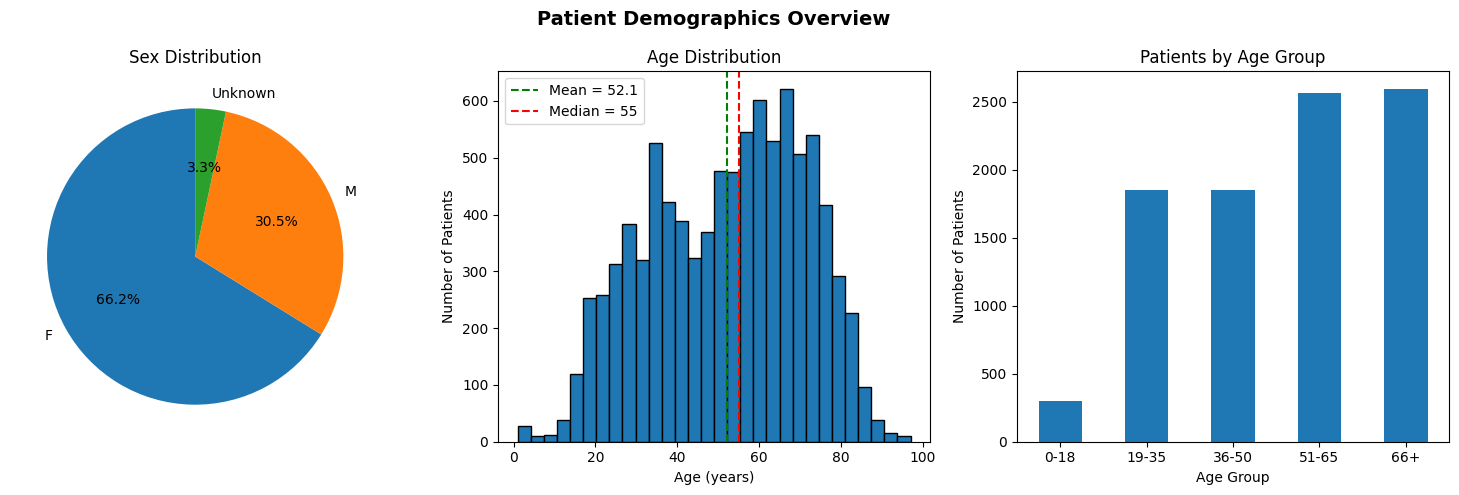

In [ ]:


plt.figure(figsize=(15,5))

# Sex Distribution
plt.subplot(1,3,1)
sex_counts = df['sex'].fillna('Unknown').value_counts()
plt.pie(sex_counts,
        labels=sex_counts.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Sex Distribution')

# Age Distribution
plt.subplot(1,3,2)
plt.hist(df['age'], bins=30, edgecolor='black')

plt.axvline(df['age'].mean(), color='green', linestyle='--',
            label=f"Mean = {df['age'].mean():.1f}")

plt.axvline(df['age'].median(), color='red', linestyle='--',
            label=f"Median = {df['age'].median():.0f}")

plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.title('Age Distribution')
plt.legend()

# Age Group Distribution
plt.subplot(1,3,3)
df['age_group'].value_counts().sort_index().plot.bar()
plt.title('Patients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

plt.suptitle('Patient Demographics Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Demographic Insights

- The dataset is female-dominant, with females representing 66.2% of patients and males 30.5%.
- Most patients are middle-aged or older, with a median age of 55 years.
- A small proportion of records (3.3%) have missing sex information and were excluded only from analyses requiring sex.

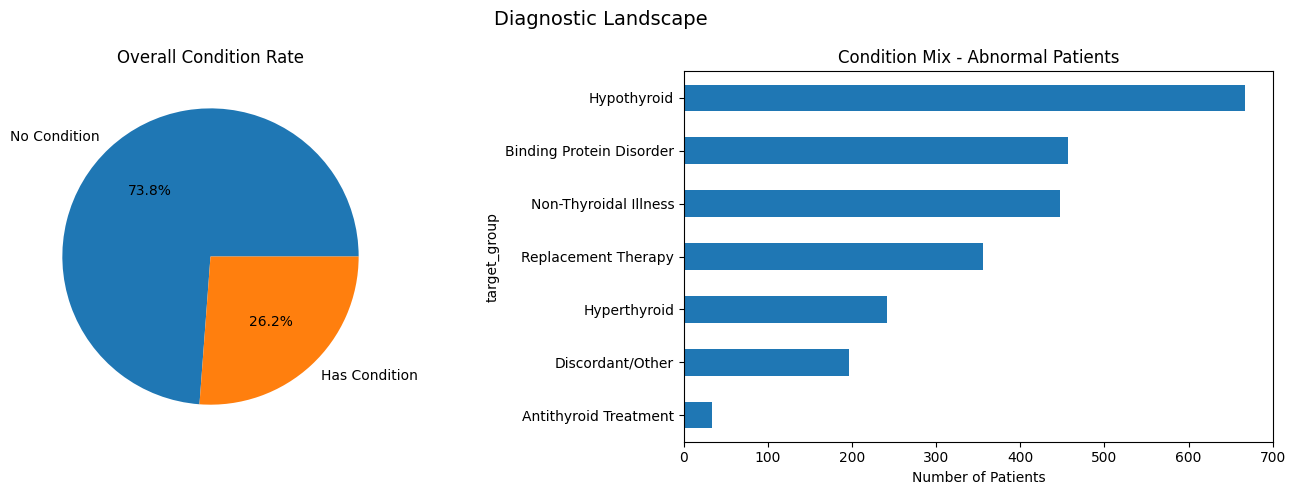

In [ ]:
df['is_abnormal']   = df['target'].str.strip() != '-'

plt.figure(figsize=(14,5))

# Overall condition rate
plt.subplot(1,2,1)
df['is_abnormal'].value_counts().rename({
    False: 'No Condition',
    True: 'Has Condition'
}).plot.pie(
    autopct='%1.1f%%',
    ylabel=''
)
plt.title('Overall Condition Rate')

# Condition categories
plt.subplot(1,2,2)
(df[df['is_abnormal']]['target_group']
 .value_counts()
 .sort_values()
 .plot.barh())

plt.title('Condition Mix - Abnormal Patients')
plt.xlabel('Number of Patients')

plt.suptitle('Diagnostic Landscape', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Display the frequency of each diagnosis code
code_df = (
    df[df['is_abnormal']]
    .groupby(['primary_code', 'target_name', 'target_group'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

print(code_df)

   primary_code                target_name              target_group  Count
10            K      Non-Thyroidal Illness     Non-Thyroidal Illness    447
6             G    Compensated Hypothyroid               Hypothyroid    419
8             I  Increased Binding Protein  Binding Protein Disorder    344
5             F        Primary Hypothyroid               Hypothyroid    239
17            R   Discordant Assay Results          Discordant/Other    196
0             A               Hyperthyroid              Hyperthyroid    193
12            M              Underreplaced       Replacement Therapy    129
11            L        Replacement Therapy       Replacement Therapy    116
13            N               Overreplaced       Replacement Therapy    110
18            S               Elevated TBG  Binding Protein Disorder     83
9             J  Decreased Binding Protein  Binding Protein Disorder     30
1             B                   T3 Toxic              Hyperthyroid     21
2           

### Diagnosis Mapping Insights

- Around one in four patients had an abnormal thyroid diagnosis, with **Hypothyroidism** being the largest diagnosis group.
- **Non-Thyroidal Illness** was the second most common abnormal diagnosis, showing that thyroid test abnormalities can occur due to illnesses outside the thyroid gland.
- **Binding Protein Disorders** formed another important group, as changes in thyroid-binding proteins can affect hormone test results without necessarily indicating true thyroid dysfunction.

Text(0.5, 0, 'Number of Patients')

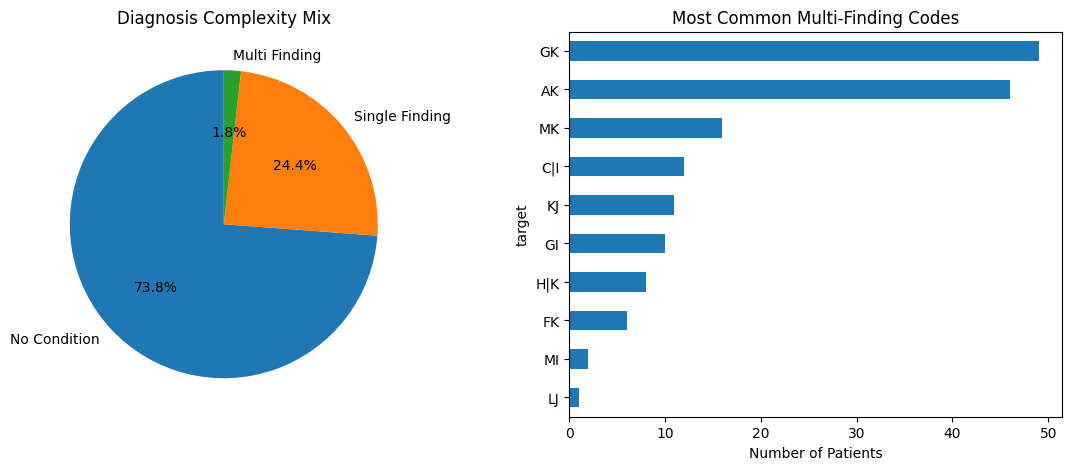

In [ ]:

df['is_pipe_code']  = df['target'].str.contains('|', regex=False)
df['is_compound']   = (~df['is_pipe_code']) & (df['target'].str.strip().str.len() > 1)
df['multi_finding'] = df['is_pipe_code'] | df['is_compound']

plt.figure(figsize=(14,5))

# Diagnosis complexity
plt.subplot(1,2,1)

complexity = {
    'No Condition': (~df['is_abnormal']).sum(),
    'Single Finding': df[(df['is_abnormal']) & (~df['multi_finding'])].shape[0],
    'Multi Finding': df['multi_finding'].sum()
}

plt.pie(
    complexity.values(),
    labels=complexity.keys(),
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Diagnosis Complexity Mix')

# Most common multi-finding codes
plt.subplot(1,2,2)

top10 = df[df['multi_finding']]['target'].value_counts().head(10)
top10.sort_values().plot.barh()

plt.title('Most Common Multi-Finding Codes')
plt.xlabel('Number of Patients')

### Multi-Finding Diagnosis Insights

- Only **164 patients (1.8%)** had multi-finding diagnoses, indicating that most patients were assigned a single primary diagnosis.
- **GK (Compensated Hypothyroid + Non-Thyroidal Illness)** was the most common compound diagnosis, showing that multiple thyroid-related findings can occur in the same patient.
- Pipe-notation codes (e.g., **C|I**) indicate diagnostic uncertainty, where more than one diagnosis may explain the laboratory findings.

---
## Univariate Analysis

Univariate analysis examines **each variable independently** to understand its distribution, frequency, and overall characteristics. This provides an overview of the dataset and helps identify patterns, class imbalance, skewness, and unusual values before exploring relationships between variables.


In [ ]:
# Display summary statistics for continuous variables
CONT_COLS = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

summary = df[CONT_COLS].describe().T
summary['Missing (%)'] = (df[CONT_COLS].isnull().mean() * 100).round(1)

summary

,count,mean,std,min,25%,50%,75%,max,Missing (%)
age,9154.0,52.093511,18.911248,1.000,37.0000,55.00,67.00,97.00,0.0
TSH,8320.0,5.223552,24.198070,0.005,0.4675,1.40,2.70,530.00,9.1
T3,6560.0,1.970319,0.887957,0.050,1.5000,1.90,2.30,18.00,28.3
TT4,8720.0,108.689181,37.536770,2.000,87.0000,104.00,126.00,600.00,4.7
T4U,8353.0,0.975859,0.200157,0.170,0.8600,0.96,1.06,2.33,8.8
FTI,8360.0,113.648450,41.569080,1.400,93.0000,109.00,128.00,881.00,8.7


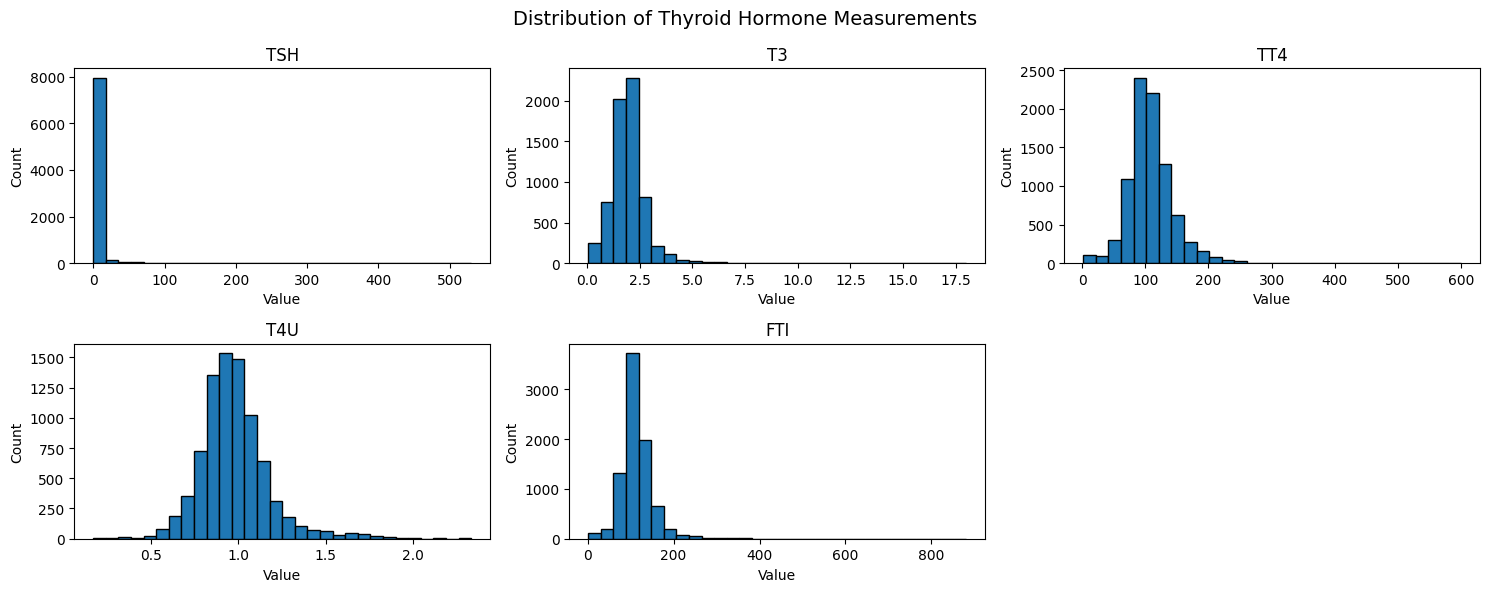

In [ ]:
# Visualize the distribution of thyroid hormone measurements

HORMONES = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

plt.figure(figsize=(15,6))

for i, hormone in enumerate(HORMONES, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[hormone].dropna(), bins=30, edgecolor='black')
    plt.title(hormone)
    plt.xlabel('Value')
    plt.ylabel('Count')

plt.suptitle('Distribution of Thyroid Hormone Measurements', fontsize=14)
plt.tight_layout()
plt.show()

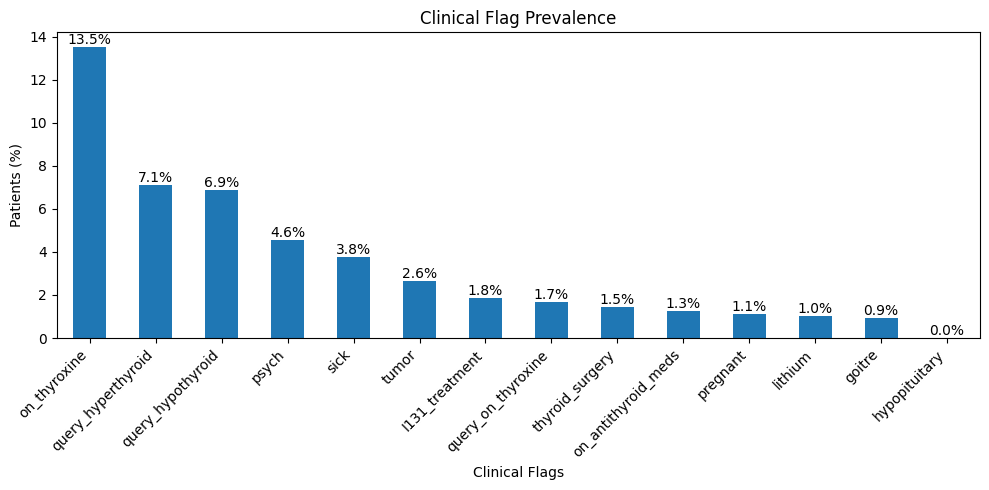

In [ ]:
# Visualize the prevalence of clinical condition flags
FLAG_COLS     = ['on_thyroxine','query_on_thyroxine','on_antithyroid_meds',
                 'sick','pregnant','thyroid_surgery','I131_treatment',
                 'query_hypothyroid','query_hyperthyroid','lithium',
                 'goitre','tumor','hypopituitary','psych']

flag_prev = (df[FLAG_COLS] == 't').mean() * 100
flag_prev = flag_prev.sort_values(ascending=False)

ax = flag_prev.plot.bar(figsize=(10,5))

# Add percentage labels
ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.title('Clinical Flag Prevalence')
plt.xlabel('Clinical Flags')
plt.ylabel('Patients (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

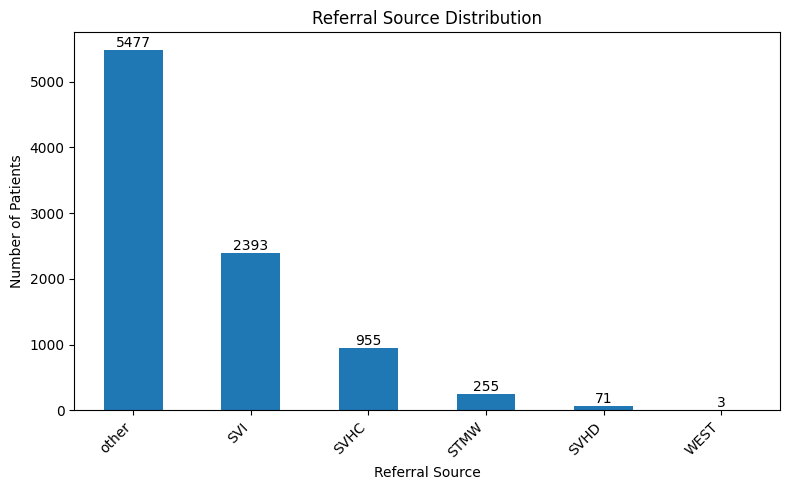

In [ ]:
# Visualize the distribution of referral sources
ax = df['referral_source'].value_counts().plot.bar(figsize=(8,5))

# Add count labels
ax.bar_label(ax.containers[0])

plt.title('Referral Source Distribution')
plt.xlabel('Referral Source')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Univariate Findings Summary

**Hormone Measurements**

- TSH shows the greatest variability among the thyroid hormone measurements.
- Most hormone values fall within expected clinical ranges, although a small number of extreme values are present.
- The clinical significance of these extreme hormone values will be examined further during the outlier validation.

**Clinical Flags**

- `on_thyroxine` is the most common clinical flag, indicating that many patients were already receiving thyroid hormone replacement therapy.
- Most other clinical flags are relatively uncommon.

**Referral Source**

- Referral Source Patients were referred through multiple healthcare pathways, with referrals concentrated among a few major sources.
- Referral source will be further investigated in the bivariate analysis to assess its association with thyroid diagnoses.

---
## Bivariate Analysis

Bivariate analysis explores the relationship between **two variables** to identify patterns and associations within the dataset.

This section examines:
- Relationships between thyroid hormone measurements.
- Patient characteristics and thyroid diagnoses.
- Hormone levels across diagnosis groups.
- Clinical flags and referral sources in relation to thyroid diagnoses.

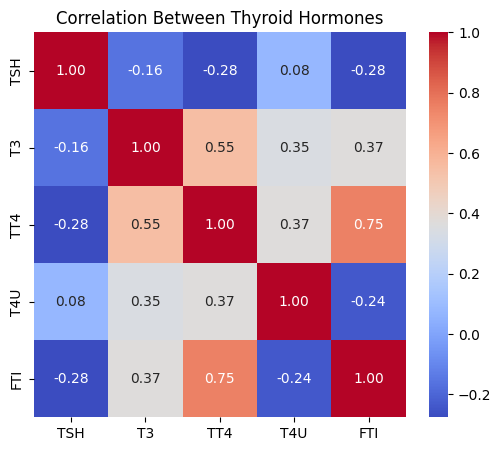

In [ ]:
corr = df[['TSH', 'T3', 'TT4', 'T4U', 'FTI']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Between Thyroid Hormones')
plt.show()

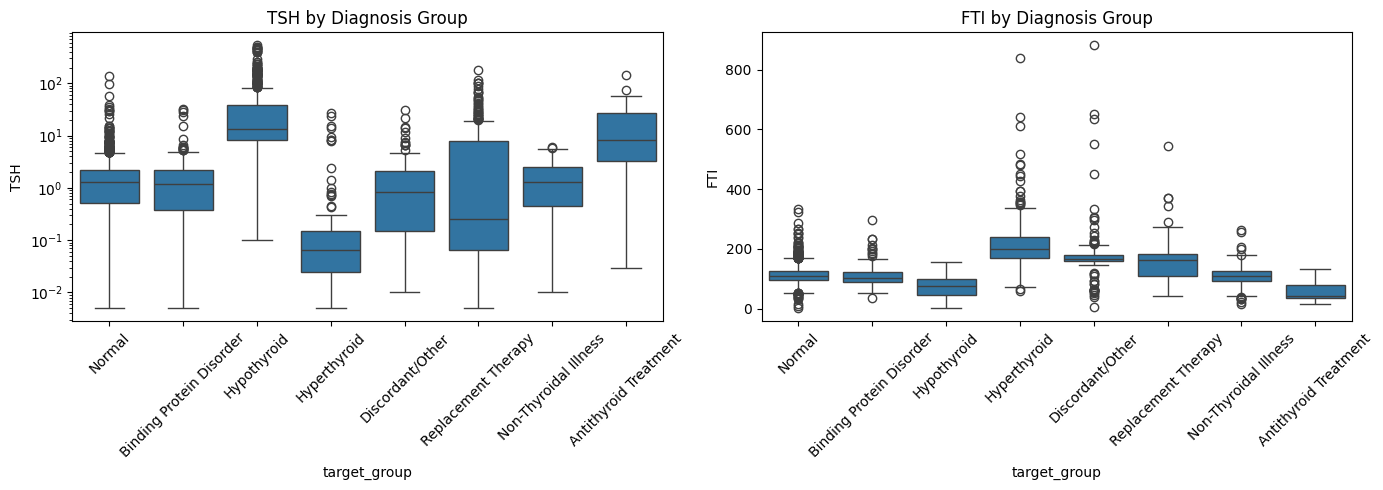

In [ ]:
# Compare TSH and FTI across diagnosis groups
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x='target_group', y='TSH', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('TSH by Diagnosis Group')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='target_group', y='FTI', ax=axes[1])
axes[1].set_title('FTI by Diagnosis Group')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate Odds Ratio for each clinical flag

from scipy.stats import chi2_contingency

results = []

for flag in FLAG_COLS:

    table = pd.crosstab(df[flag], df["is_abnormal"])

    # Skip flags with zero cells (e.g., hypopituitary)
    if (table == 0).any().any():
        continue

    a = table.loc["t", True]
    b = table.loc["t", False]
    c = table.loc["f", True]
    d = table.loc["f", False]

    # Odds Ratio
    or_value = (a * d) / (b * c)

    # Chi-square p-value
    _, p, _, _ = chi2_contingency(table)

    results.append([flag, or_value, p])

or_df = pd.DataFrame(
    results,
    columns=["Clinical Flag", "Odds Ratio", "P-value"]
).sort_values("Odds Ratio", ascending=False)

display(or_df)

,Clinical Flag,Odds Ratio,P-value
4,pregnant,7.762320,8.874119e-27
7,query_hypothyroid,1.580442,1.575179e-07
0,on_thyroxine,1.555660,1.325282e-11
11,tumor,1.387438,2.227097e-02
8,query_hyperthyroid,1.381929,2.481430e-04
2,on_antithyroid_meds,1.221292,3.806257e-01
6,I131_treatment,1.087705,6.915065e-01
1,query_on_thyroxine,0.997819,1.000000e+00
5,thyroid_surgery,0.882809,6.084126e-01
3,sick,0.878093,3.435219e-01


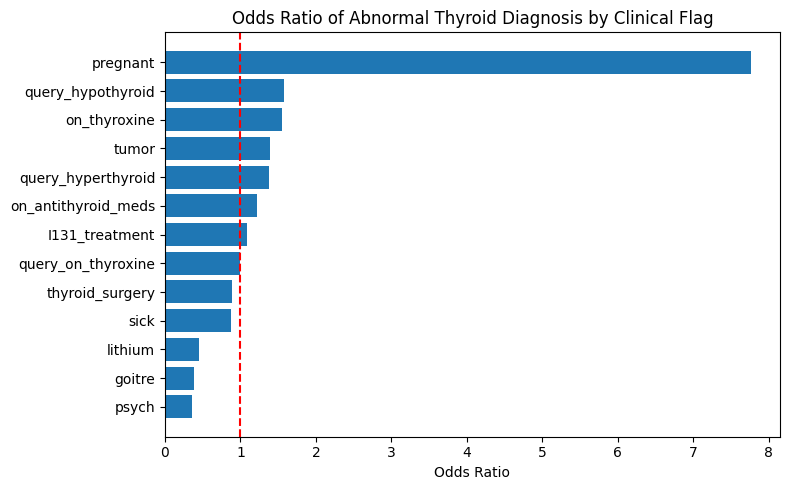

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(or_df["Clinical Flag"], or_df["Odds Ratio"])
plt.axvline(1, color="red", linestyle="--")

plt.xlabel("Odds Ratio")
plt.title("Odds Ratio of Abnormal Thyroid Diagnosis by Clinical Flag")

plt.gca().invert_yaxis()   # Largest OR at the top
plt.tight_layout()
plt.show()

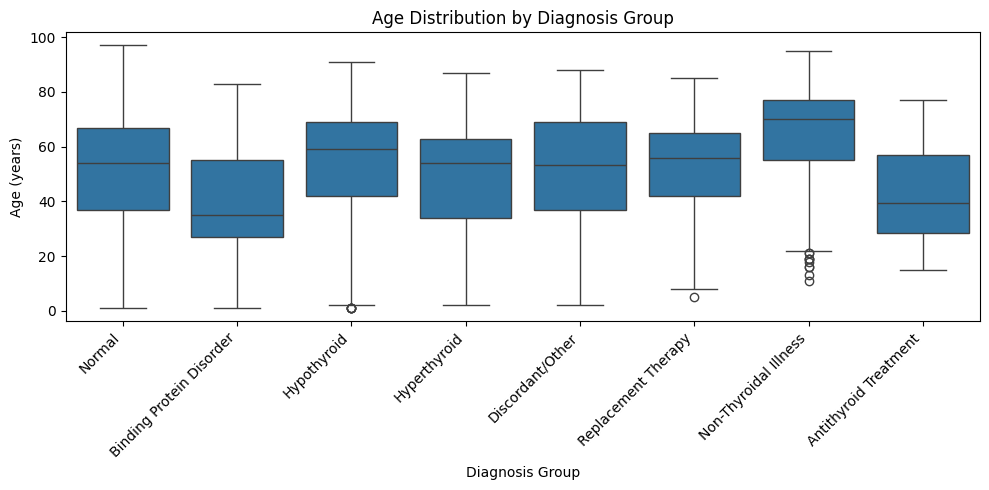

In [ ]:
# Compare age across diagnosis groups
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='target_group',
    y='age'
)

plt.title('Age Distribution by Diagnosis Group')
plt.xlabel('Diagnosis Group')
plt.ylabel('Age (years)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Bivariate Analysis Findings Summary

#### Hormone Relationships
- TT4 and FTI have the strongest positive relationship, meaning they tend to increase and decrease together.
- TSH has only a weak relationship with the other hormone tests, showing that it provides different but important information about thyroid function.

#### Hormone Levels by Diagnosis
- Hormone levels differ across thyroid diagnosis groups.
- TSH shows the clearest difference between hypothyroid, hyperthyroid, and normal patients, making it an important screening test.
- FTI also helps distinguish diagnosis groups and provides additional information alongside TT4.

#### Clinical Flags and Thyroid Disease
- Some clinical conditions are linked to a higher chance of an abnormal thyroid diagnosis.
- Patients who have had thyroid surgery, I131 treatment, or are taking thyroxine are more likely to have thyroid disease.
- A patient's medical history can therefore help identify those at higher risk.

#### Age and Thyroid Disease
- The age distribution varies across diagnosis groups.
- Some thyroid conditions are more common in older patients, so age is an important factor when interpreting thyroid disease.

#### Referral Source
- The pattern of thyroid diagnoses differs depending on the referral source.
- This suggests that referral information may help identify patients who are more likely to have an abnormal thyroid condition.

---
## Hormone Outlier Analysis

This section investigates extreme hormone values to determine whether they represent genuine clinical findings or potential data quality issues. It also validates the relationship between TT4 and FTI to assess the consistency of hormone measurements.

In [ ]:
# Summary statistics for hormone measurements
df[PLOT_HORMONES].describe().round(2)

,TSH,T3,TT4,T4U,FTI
count,8320.00,6560.00,8720.00,8353.00,8360.00
mean,5.22,1.97,108.69,0.98,113.65
std,24.20,0.89,37.54,0.20,41.57
min,0.00,0.05,2.00,0.17,1.40
25%,0.47,1.50,87.00,0.86,93.00
50%,1.40,1.90,104.00,0.96,109.00
75%,2.70,2.30,126.00,1.06,128.00
max,530.00,18.00,600.00,2.33,881.00


In [ ]:
# Check whether hormone outliers are associated with thyroid disorders
PLOT_HORMONES = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

results = []

for hormone in PLOT_HORMONES:

    Q1 = df[hormone].quantile(0.25)
    Q3 = df[hormone].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[hormone] < lower) | (df[hormone] > upper)]

    clinical = outliers['target_group'].isin(['Hypothyroid', 'Hyperthyroid']).mean() * 100

    results.append([
        hormone,
        len(outliers),
        round(clinical, 1)
    ])

outlier_summary = pd.DataFrame(
    results,
    columns=['Hormone', 'Outliers', 'Hypo/Hyper (%)']
)

outlier_summary

,Hormone,Outliers,Hypo/Hyper (%)
0,TSH,884,75.3
1,T3,360,43.6
2,TT4,422,52.8
3,T4U,422,9.7
4,FTI,501,54.9


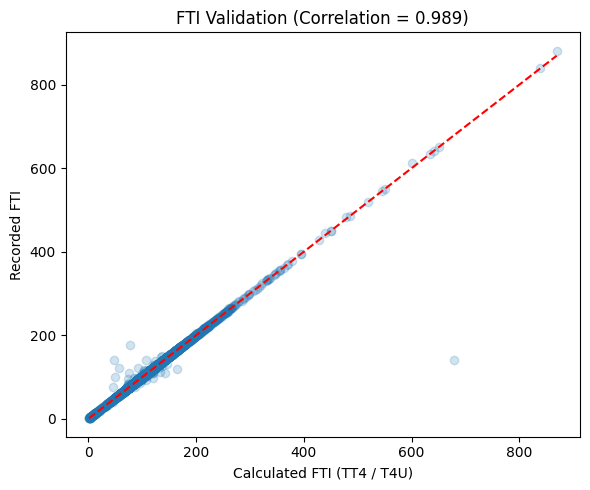

Correlation: 0.989


In [ ]:
# Validate the FTI calculation
both = df[['TT4', 'T4U', 'FTI']].dropna().copy()

both['Calculated_FTI'] = both['TT4'] / both['T4U']

corr = both['FTI'].corr(both['Calculated_FTI'])

plt.figure(figsize=(6,5))

plt.scatter(
    both['Calculated_FTI'],
    both['FTI'],
    alpha=0.2
)

plt.plot(
    [both['Calculated_FTI'].min(), both['Calculated_FTI'].max()],
    [both['Calculated_FTI'].min(), both['Calculated_FTI'].max()],
    color='red',
    linestyle='--'
)

plt.title(f'FTI Validation (Correlation = {corr:.3f})')
plt.xlabel('Calculated FTI (TT4 / T4U)')
plt.ylabel('Recorded FTI')

plt.tight_layout()
plt.show()

print(f'Correlation: {corr:.3f}')

### Interpretation

- **Outlier validation:** Most hormone outliers are associated with confirmed hypothyroid or hyperthyroid patients, indicating that these extreme values represent genuine clinical findings rather than data errors. Therefore, all outliers were retained for subsequent analyses.

- **FTI validation:** The recorded FTI values show an almost perfect correlation (**r = 0.989**) with the calculated TT4 ÷ T4U values, confirming the internal consistency and reliability of the hormone measurements.

In [ ]:
# Median hormone values by diagnosis group
median_table = (
    df.groupby('target_group')[PLOT_HORMONES]
      .median()
      .round(2)
)

median_table

,TSH,T3,TT4,T4U,FTI
target_group,,,,,
Antithyroid Treatment,8.30,1.4,44.0,1.03,42.0
Binding Protein Disorder,1.20,3.1,149.0,1.37,103.5
Discordant/Other,0.84,1.9,146.0,0.88,165.0
Hyperthyroid,0.06,3.6,178.0,0.92,198.0
Hypothyroid,13.10,1.4,75.0,0.99,77.0
Non-Thyroidal Illness,1.30,0.9,88.0,0.82,108.0
Normal,1.30,2.0,104.0,0.96,109.0
Replacement Therapy,0.25,2.0,153.5,0.97,163.0


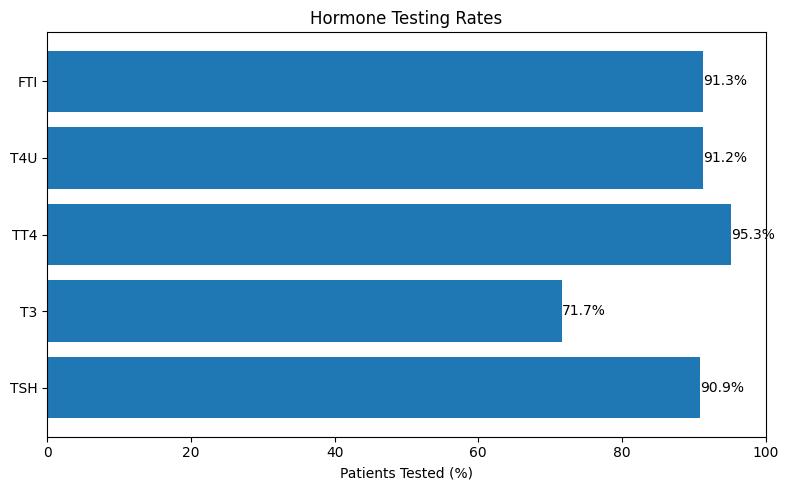

In [ ]:
# Percentage of patients tested for each hormone
tests = {
    'TSH': (df['TSH_measured'] == 't').mean() * 100,
    'T3' : (df['T3_measured'] == 't').mean() * 100,
    'TT4': (df['TT4_measured'] == 't').mean() * 100,
    'T4U': (df['T4U_measured'] == 't').mean() * 100,
    'FTI': (df['FTI_measured'] == 't').mean() * 100
}

plt.figure(figsize=(8,5))

ax = plt.barh(
    list(tests.keys()),
    list(tests.values())
)

plt.bar_label(ax, fmt='%.1f%%')

plt.xlabel('Patients Tested (%)')
plt.title('Hormone Testing Rates')

plt.xlim(0,100)
plt.tight_layout()
plt.show()

**Observation:**

- TSH, TT4, T4U, and FTI were measured in most patients.
- T3 was ordered less frequently than the other routine thyroid hormone tests.


In [ ]:
#T3 measured in target_groups
t3_by_target = (
    pd.crosstab(
        df["target_group"],
        df["T3_measured"],
        normalize="index"
    ) * 100
).round(1)

t3_by_target = t3_by_target.sort_values(by="t", ascending=False)

display(t3_by_target)

T3_measured,f,t
target_group,,
Antithyroid Treatment,0.0,100.0
Non-Thyroidal Illness,2.2,97.8
Discordant/Other,11.7,88.3
Hyperthyroid,14.9,85.1
Hypothyroid,24.6,75.4
Normal,29.6,70.4
Replacement Therapy,38.6,61.4
Binding Protein Disorder,48.6,51.4


In [ ]:
#T3 measured in clinical flags
results = []

for flag in FLAG_COLS:
    total = (df[flag] == "t").sum()
    measured = ((df[flag] == "t") & (df["T3_measured"] == "t")).sum()

    results.append({
        "Clinical Flag": flag,
        "Total Patients": total,
        "T3 Measured": measured,
        "Percent": round(measured / total * 100, 1)
    })

# Create DataFrame
flag_percent = pd.DataFrame(results)

# Remove very rare flags
flag_percent = flag_percent[flag_percent["Total Patients"] >= 10]

# Sort by percentage
flag_percent = flag_percent.sort_values("Percent", ascending=False)

display(flag_percent)

,Clinical Flag,Total Patients,T3 Measured,Percent
13,psych,418,366,87.6
2,on_antithyroid_meds,116,101,87.1
8,query_hyperthyroid,649,515,79.4
4,pregnant,103,78,75.7
6,I131_treatment,169,125,74.0
9,lithium,93,68,73.1
3,sick,344,251,73.0
5,thyroid_surgery,134,96,71.6
7,query_hypothyroid,629,430,68.4
10,goitre,84,55,65.5


### T3 Measurement Patterns

- T3 was measured less frequently than the other routine thyroid hormone tests.
- T3 testing was more common in patients with known or suspected thyroid disorders, especially those receiving antithyroid treatment or being evaluated for hyperthyroidism.
- T3 was also frequently measured in patients with Non-Thyroidal Illness, suggesting that clinicians requested it in more complex clinical cases.

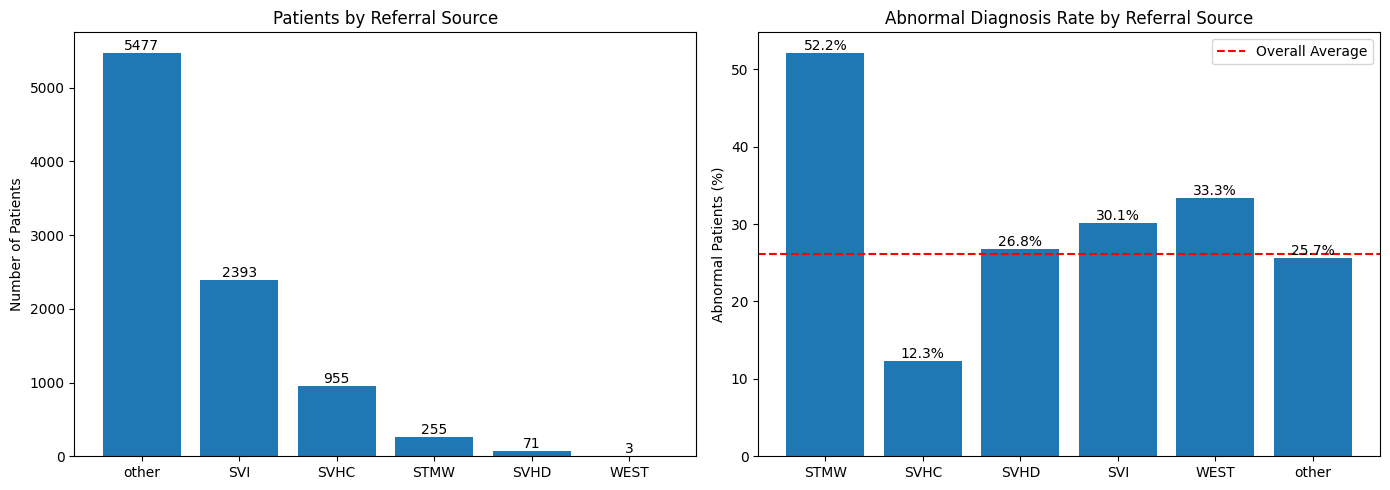

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Patient volume
ref_count = df['referral_source'].value_counts()

axes[0].bar(ref_count.index, ref_count.values)

axes[0].bar_label(axes[0].containers[0])

axes[0].set_title('Patients by Referral Source')
axes[0].set_ylabel('Number of Patients')

# Abnormal rate
ref_rate = (
    df.groupby('referral_source')['is_abnormal']
      .mean() * 100
)

axes[1].bar(ref_rate.index, ref_rate.values)

axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%')

axes[1].axhline(
    df['is_abnormal'].mean()*100,
    color='red',
    linestyle='--',
    label='Overall Average'
)

axes[1].set_title('Abnormal Diagnosis Rate by Referral Source')
axes[1].set_ylabel('Abnormal Patients (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Referral Source Insights

- The abnormal diagnosis rate varies across referral sources.
- STMW has the highest proportion of abnormal thyroid diagnoses, while SVHC has one of the lowest.
- This suggests that referral source is associated with the likelihood of an abnormal thyroid diagnosis in this dataset.

---
## Key Findings 
### 🔑 Finding 1 — The Dataset Is Reliable for Analysis

**Finding:** Data quality checks confirmed that the dataset is suitable for analysis. Missing values were consistent with the corresponding `*_measured` flags, most hormone outliers reflected genuine thyroid conditions rather than data errors, and the calculated FTI closely matched the recorded values (r = 0.989), supporting the reliability of the hormone measurements.

---

### 🔑 Finding 2 — One in Four Patients Had a Thyroid Condition

**Finding:** About **26.2% of patients** were diagnosed with a thyroid-related condition, while **73.8% had no thyroid disorder**. This means that **around one out of every four patients** in the dataset had an abnormal thyroid diagnosis.

---

### 🔑 Finding 3 — Hypothyroidism Is the Most Common Abnormal Diagnosis

**Finding:** Hypothyroidism was the most common abnormal diagnosis. Non-Thyroidal Illness also represented a substantial patient group, and its TSH values often overlapped with those of normal patients, suggesting that TSH alone may not always distinguish these cases.

---

### 🔑 Finding 4 — TSH Is the Best Screening Biomarker, but Should Not Be Used Alone

**Finding:** TSH provided the clearest separation between hypothyroid, hyperthyroid, and normal patients. However, some diagnosis groups, including Non-Thyroidal Illness and Binding Protein Disorders, showed relatively normal TSH values, highlighting the importance of interpreting TSH alongside other thyroid hormone tests.

---

### 🔑 Finding 5 — FTI Improves the Interpretation of TT4

**Finding:** TT4 and FTI showed a strong positive relationship. FTI provides additional information alongside TT4, particularly when thyroid hormone binding is altered, making it a valuable complementary measurement.

---

### 🔑 Finding 6 — Clinical History Supports Risk Assessment

**Finding:** Several clinical flags, including pregnancy, suspected thyroid disease, and previous thyroid treatment, were associated with higher rates of abnormal thyroid diagnoses. Referral patterns also differed across diagnosis groups, suggesting that patient history and referral information can help identify individuals at higher risk.